**Name : Gaurang Tyagi**

**Roll No. : 16**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

# Iris Dataset

- Number of instances : 150
- Number of Attributes : 4
- Attribute Information : 
    - Sepal Length in cm
    - Sepal Width in cm
    - Petal Length in cm
    - Petal Width in cm
- Class : 
    - Iris-Setosa
    - Iris-Versicolar
    - Iris-Virginica

# Loading data

In [2]:
iris = load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

## Preview of Data

In [3]:
X = pd.DataFrame(iris.data,columns=iris.feature_names)
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
y = pd.Series(iris.target,name="class")
y.head()

0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64

# Distribution of class

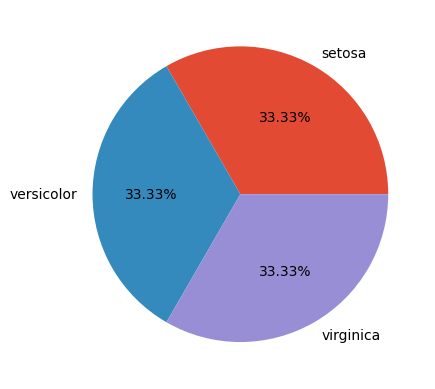

In [5]:
plt.style.use("ggplot")
pie_data = y.value_counts(normalize=True)
plt.pie(pie_data,labels=iris.target_names,autopct="%.2f%%")
plt.show()

## Information about data

In [6]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
X.info() 

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


# Preprocessing

## Applying normalization

In [8]:
scaler = StandardScaler()
X_scale = pd.DataFrame(scaler.fit_transform(X),columns=X.columns)
X_scale.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


# Spliting Data into train and test dataset
 - test dataset size : 20% (30 instances)
 - training dataset size : 80% (120 instances)

In [9]:
x_train,x_test,y_train,y_test = train_test_split(X_scale,y,test_size=.2,random_state=1)

# Logisitic Regression

In [10]:
log_reg = LogisticRegression()
log_classifier = log_reg.fit(x_train,y_train)
y_pred = log_classifier.predict(x_test)
y_pred

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2])

## Confusion Matrix for logistic regression

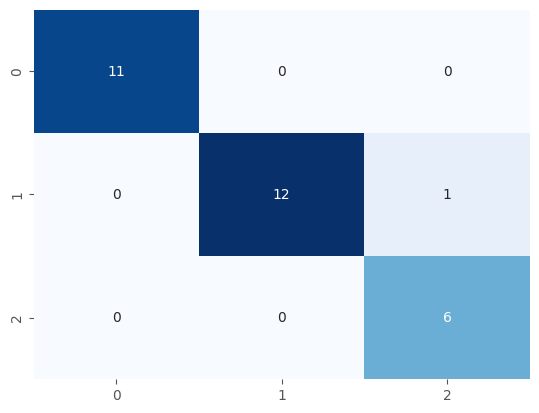

In [11]:
conf_matrix = confusion_matrix(y_true=y_test,y_pred=y_pred)
sns.heatmap(conf_matrix,annot=True,cbar=False,cmap=plt.cm.Blues)
plt.show()

## Report for logistic regression

In [12]:
log_reg_report = classification_report(y_true=y_test,y_pred=y_pred,output_dict=True)
log_reg_report = pd.DataFrame(log_reg_report)
log_reg_report

,0,1,2,accuracy,macro avg,weighted avg
precision,1.0,1.000000,0.857143,0.966667,0.952381,0.971429
recall,1.0,0.923077,1.000000,0.966667,0.974359,0.966667
f1-score,1.0,0.960000,0.923077,0.966667,0.961026,0.967282
support,11.0,13.000000,6.000000,0.966667,30.000000,30.000000


## Accuracy score for logistic regression

In [13]:
print(f"accuracy of logistic regression : {accuracy_score(y_pred=y_pred,y_true=y_test)}")

accuracy of logistic regression : 0.9666666666666667


# Multilayer Perceptron
 - hidden layers size :  10
 - No. of epochs : 500
 - activation function : relu

In [14]:
mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter = 1000,
    activation="relu",
    solver="adam"
)
mlp_classifier = mlp.fit(x_train,y_train)
y_pred_nn = mlp_classifier.predict(x_test)
y_pred_nn

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2])

## Confusion Matrix for Multilayer Perceptron (with hidden layer of size 10)

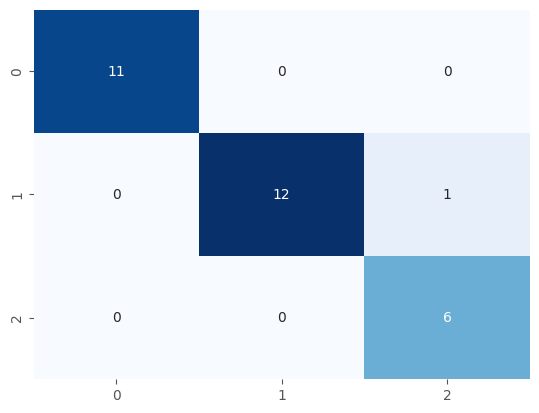

In [15]:
conf_matrix_nn = confusion_matrix(y_true=y_test,y_pred=y_pred_nn)
sns.heatmap(conf_matrix,annot=True,cbar=False,cmap=plt.cm.Blues)
plt.show()

## Report for Multilayer Perceptron (with hidden layer size 10)

In [16]:
nn_report = classification_report(y_true=y_test,y_pred=y_pred_nn,output_dict=True)
nn_report = pd.DataFrame(nn_report)
nn_report

,0,1,2,accuracy,macro avg,weighted avg
precision,1.0,1.000000,0.857143,0.966667,0.952381,0.971429
recall,1.0,0.923077,1.000000,0.966667,0.974359,0.966667
f1-score,1.0,0.960000,0.923077,0.966667,0.961026,0.967282
support,11.0,13.000000,6.000000,0.966667,30.000000,30.000000


In [17]:
print(f"accuracy score for multilayer perceptron for hidden layer size 10 : {accuracy_score(y_true=y_test,y_pred=y_pred_nn)} ")

accuracy score for multilayer perceptron for hidden layer size 10 : 0.9666666666666667 


In [18]:
mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter = 1000,
    activation="relu",
    solver="adam"
)
mlp_classifier = mlp.fit(x_train,y_train)
y_pred_nn = mlp_classifier.predict(x_test)
y_pred_nn

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2])

## Confusion Matrix for Multilayer Perceptron (with hidden layer size 50)

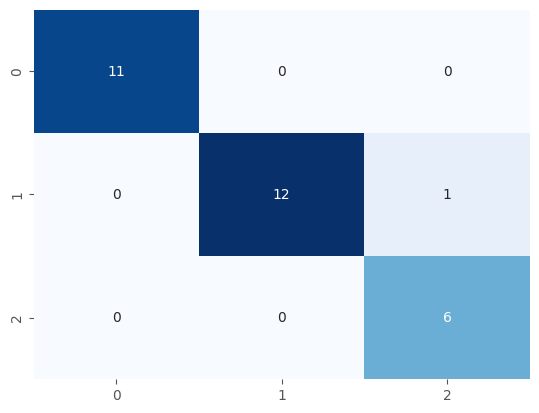

In [19]:
conf_matrix_nn = confusion_matrix(y_true=y_test,y_pred=y_pred_nn)
sns.heatmap(conf_matrix,annot=True,cbar=False,cmap=plt.cm.Blues)
plt.show()

## Report for Multiplayer Perceptron (with hidden layer size 50)

In [20]:
nn_report = classification_report(y_true=y_test,y_pred=y_pred_nn,output_dict=True)
nn_report = pd.DataFrame(nn_report)
nn_report

,0,1,2,accuracy,macro avg,weighted avg
precision,1.0,1.000000,0.857143,0.966667,0.952381,0.971429
recall,1.0,0.923077,1.000000,0.966667,0.974359,0.966667
f1-score,1.0,0.960000,0.923077,0.966667,0.961026,0.967282
support,11.0,13.000000,6.000000,0.966667,30.000000,30.000000


In [21]:
print(f"accuracy score for multilayer perceptron for hidden layer size 50 : {accuracy_score(y_true=y_test,y_pred=y_pred_nn)} ")

accuracy score for multilayer perceptron for hidden layer size 50 : 0.9666666666666667 


# Multilayer Perceptron
 - hidden layers size :  10,50
 - No. of epochs : 500
 - activation function : relu

In [22]:
mlp = MLPClassifier(
    hidden_layer_sizes=(10,50,),
    max_iter = 500,
    activation="relu",
    solver="adam"
)
mlp_classifier = mlp.fit(x_train,y_train)
y_pred_nn = mlp_classifier.predict(x_test)
y_pred_nn

/home/gaurang/d_drive/College Material/MCA_Sem2/AI_ML/practical/AI/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2])

## Confusion Matrix for Multilayer Perceptron (with hidden layer size 10,50)

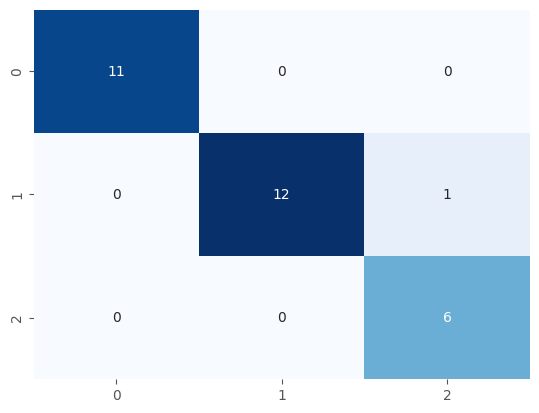

In [23]:
conf_matrix_nn = confusion_matrix(y_true=y_test,y_pred=y_pred_nn)
sns.heatmap(conf_matrix,annot=True,cbar=False,cmap=plt.cm.Blues)
plt.show()

## Classification report for Multilayer Perceptron (with hidden layer size 10,50)

In [24]:
nn_report = classification_report(y_true=y_test,y_pred=y_pred_nn,output_dict=True)
nn_report = pd.DataFrame(nn_report)
nn_report

,0,1,2,accuracy,macro avg,weighted avg
precision,1.0,1.000000,0.857143,0.966667,0.952381,0.971429
recall,1.0,0.923077,1.000000,0.966667,0.974359,0.966667
f1-score,1.0,0.960000,0.923077,0.966667,0.961026,0.967282
support,11.0,13.000000,6.000000,0.966667,30.000000,30.000000


In [25]:
print(f"accuracy score for multilayer perceptron for hidden layer size 10,50 : {accuracy_score(y_true=y_test,y_pred=y_pred_nn)} ")


accuracy score for multilayer perceptron for hidden layer size 10,50 : 0.9666666666666667 


# Conclusion:

```
accuracy score for logistic regression is 96.67%
-- Number of epochs : 1000
-- Activation function : relu
accuracy score for Multilayer perceptron with hidden layer size 10 : 96.67%
accuracy score for Multilayer perceptron with hidden layer size 50 : 96.67%
accuracy score for Multilayer perceptron with hidden layer sizes 10,50 : 96.67%
```